# Correlação e Covariância — Prática com Python

## 1. Importando bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Dataset de peso, altura e idade

Vamos criar um dataset simulado com peso, altura e idade de 100 pessoas. Na vida real, esperaríamos que peso e altura estivessem positivamente correlacionados.

In [3]:
np.random.seed(42)
n = 100

# Altura em cm (média 168, desvio ~10)
altura = np.random.normal(168, 10, n)

# Peso em kg — correlacionado com altura + ruído
# Pessoas mais altas tendem a pesar mais: peso ≈ 0.8 * altura - 60 + ruído
peso = 0.8 * altura - 60 + np.random.normal(0, 5, n)

# Idade — não correlacionada com peso/altura neste dataset
idade = np.random.randint(18, 65, n)

dados = pd.DataFrame({
    'Altura (cm)': altura,
    'Peso (kg)': peso,
    'Idade': idade
})

dados.head(10)

,Altura (cm),Peso (kg),Idade
0,172.967142,71.296860,19
1,166.617357,71.190659,43
2,174.476885,77.867936,34
3,183.230299,82.572853,57
4,165.658466,71.720344,50
5,165.658630,74.547159,26
6,183.792128,96.464632,60
7,175.674347,81.412367,56
8,163.305256,71.931957,46
9,173.425600,78.368251,59


## 3. Visualização: gráfico de dispersão

O gráfico de dispersão nos dá uma intuição visual sobre a relação entre variáveis.

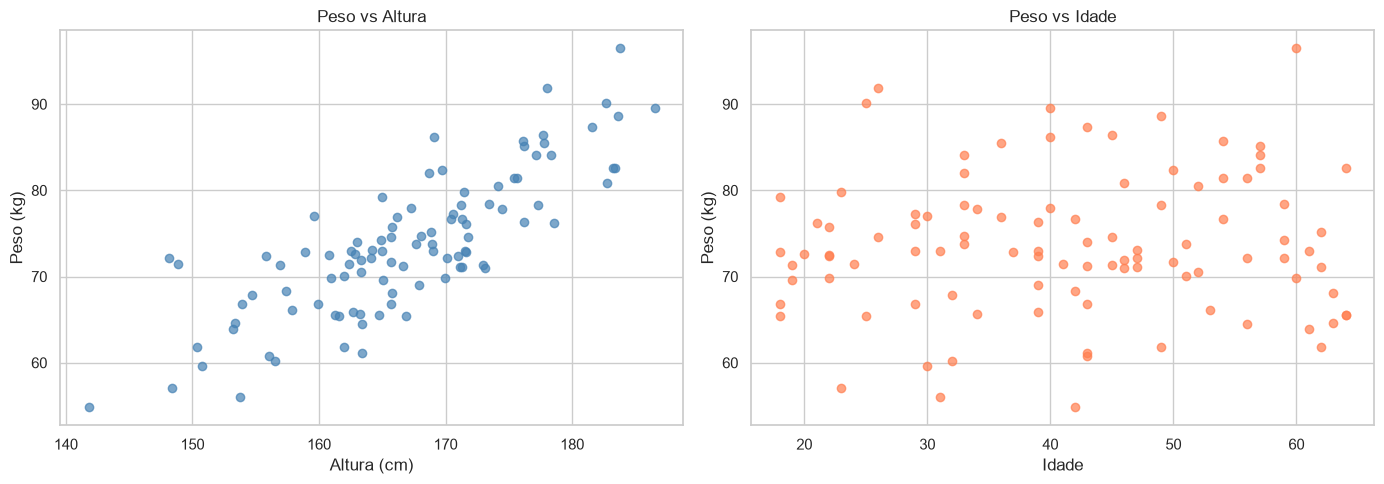

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peso vs Altura
axes[0].scatter(dados['Altura (cm)'], dados['Peso (kg)'], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Altura (cm)')
axes[0].set_ylabel('Peso (kg)')
axes[0].set_title('Peso vs Altura')

# Peso vs Idade
axes[1].scatter(dados['Idade'], dados['Peso (kg)'], alpha=0.7, color='coral')
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('Peso (kg)')
axes[1].set_title('Peso vs Idade')

plt.tight_layout()
plt.show()

## 4. Covariância

A covariância mede como duas variáveis variam juntas:

$$\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

- **Positiva**: quando uma aumenta, a outra tende a aumentar
- **Negativa**: quando uma aumenta, a outra tende a diminuir
- **Próxima de 0**: sem relação linear

In [5]:
# Matriz de covariância
cov_matrix = dados.cov()
print('Matriz de Covariância:')
print(cov_matrix.round(2))
print()

# Covariância específica entre peso e altura
cov_peso_altura = dados['Peso (kg)'].cov(dados['Altura (cm)'])
print(f'Cov(Peso, Altura) = {cov_peso_altura:.2f}')

Matriz de Covariância:
             Altura (cm)  Peso (kg)   Idade
Altura (cm)        82.48      60.07   12.05
Peso (kg)          60.07      66.07    6.88
Idade              12.05       6.88  186.46

Cov(Peso, Altura) = 60.07


### Interpretação

- `Cov(Peso, Altura) > 0` → peso e altura variam na mesma direção ✅
- `Cov(Peso, Idade) ≈ 0` → não há relação linear entre peso e idade

⚠️ **Problema**: o valor da covariância depende da escala. Não conseguimos comparar diretamente covariâncias de pares diferentes.

## 5. Correlação de Pearson

A correlação normaliza a covariância pelos desvios padrão:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

Resultado sempre entre **−1 e +1**.

In [6]:
# Matriz de correlação
corr_matrix = dados.corr()
print('Matriz de Correlação (Pearson):')
print(corr_matrix.round(3))

Matriz de Correlação (Pearson):
             Altura (cm)  Peso (kg)  Idade
Altura (cm)        1.000      0.814  0.097
Peso (kg)          0.814      1.000  0.062
Idade              0.097      0.062  1.000


### Visualização: heatmap de correlação

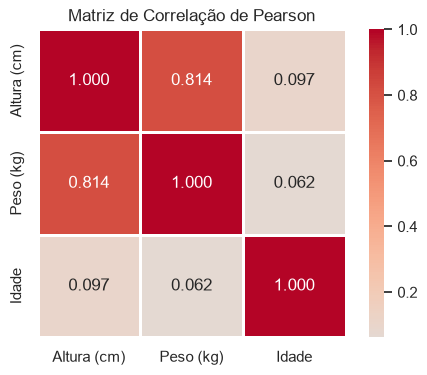

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=2)
plt.title('Matriz de Correlação de Pearson')
plt.show()

## 6. Exercícios

### Exercício 1: Correlação forte positiva

Crie dois datasets perfeitamente correlacionados e verifique o valor de r.

Correlação (forte positiva): r = 0.996


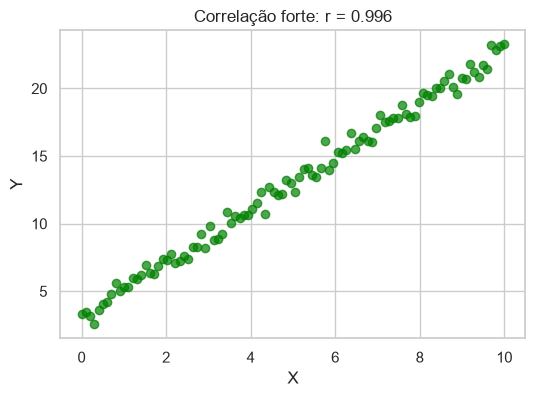

In [8]:
# Exercício 1: correlação forte positiva
x1 = np.linspace(0, 10, 100)
y1 = 2 * x1 + 3 + np.random.normal(0, 0.5, 100)  # relação linear forte

df1 = pd.DataFrame({'X': x1, 'Y': y1})
r1 = df1['X'].corr(df1['Y'])

print(f'Correlação (forte positiva): r = {r1:.3f}')

plt.figure(figsize=(6, 4))
plt.scatter(df1['X'], df1['Y'], alpha=0.7, color='green')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Correlação forte: r = {r1:.3f}')
plt.show()

### Exercício 2: Correlação forte negativa

Correlação (forte negativa): r = -0.998


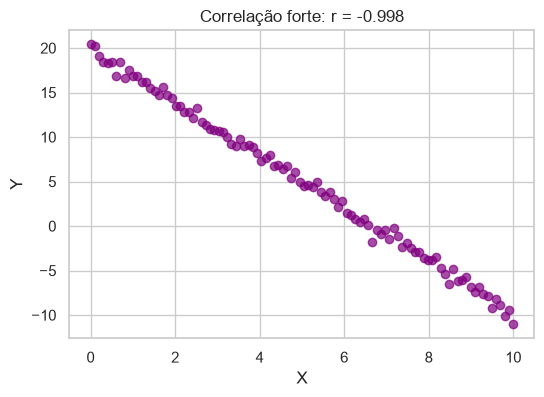

In [9]:
# Exercício 2: correlação forte negativa
x2 = np.linspace(0, 10, 100)
y2 = -3 * x2 + 20 + np.random.normal(0, 0.5, 100)

df2 = pd.DataFrame({'X': x2, 'Y': y2})
r2 = df2['X'].corr(df2['Y'])

print(f'Correlação (forte negativa): r = {r2:.3f}')

plt.figure(figsize=(6, 4))
plt.scatter(df2['X'], df2['Y'], alpha=0.7, color='purple')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Correlação forte: r = {r2:.3f}')
plt.show()

### Exercício 3: Sem correlação linear

Correlação (sem relação): r = 0.130


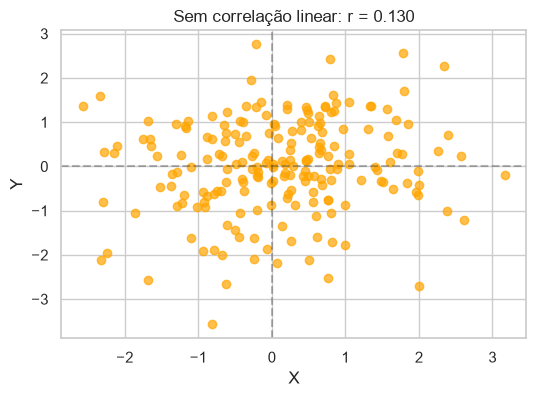

In [10]:
# Exercício 3: sem correlação linear
x3 = np.random.normal(0, 1, 200)
y3 = np.random.normal(0, 1, 200)  # independente de x3

df3 = pd.DataFrame({'X': x3, 'Y': y3})
r3 = df3['X'].corr(df3['Y'])

print(f'Correlação (sem relação): r = {r3:.3f}')

plt.figure(figsize=(6, 4))
plt.scatter(df3['X'], df3['Y'], alpha=0.7, color='orange')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Sem correlação linear: r = {r3:.3f}')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.show()

### Exercício 4: ⚠️ Armadilha — Correlação alta mas relação não-linear

Este é o momento crucial! Crie dados com relação quadrática perfeita ($y = x^2$) e veja o que acontece com a correlação de Pearson.

Relação: y = x² (perfeita)
Correlação de Pearson: r = 0.000

⚠️  A correlação é próxima de zero, mas a relação é PERFEITA!
⚠️  Pearson só captura relações LINEARES.


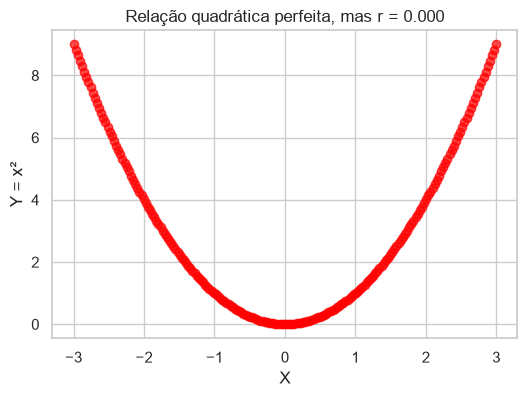

In [11]:
# Exercício 4: relação não-linear (parábola)
x4 = np.linspace(-3, 3, 200)
y4 = x4 ** 2  # relação perfeita: y = x²

df4 = pd.DataFrame({'X': x4, 'Y': y4})
r4 = df4['X'].corr(df4['Y'])

print(f'Relação: y = x² (perfeita)')
print(f'Correlação de Pearson: r = {r4:.3f}')
print()
print('⚠️  A correlação é próxima de zero, mas a relação é PERFEITA!')
print('⚠️  Pearson só captura relações LINEARES.')

plt.figure(figsize=(6, 4))
plt.scatter(df4['X'], df4['Y'], alpha=0.7, color='red')
plt.xlabel('X')
plt.ylabel('Y = x²')
plt.title(f'Relação quadrática perfeita, mas r = {r4:.3f}')
plt.show()

### Exercício 5: ⚠️ Correlação ≠ Causalidade

Exemplo clássico: vendas de sorvete e afogamentos estão correlacionados, mas um não causa o outro — o **verão** (temperatura) é o fator comum.

Correlação Sorvete × Afogamentos: r = 0.688

⚠️  Correlação alta, mas NÃO significa que sorvete causa afogamentos!
⚠️  O fator comum é a TEMPERATURA (confundidor).


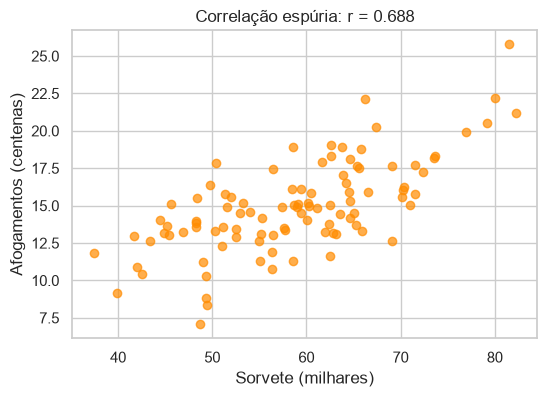

In [12]:
# Exercício 5: Correlação espúria
np.random.seed(100)
temperatura = np.random.normal(30, 5, 100)  # temperatura em °C

sorvete = 2 * temperatura + np.random.normal(0, 3, 100)   # mais calor → mais sorvete
afogamentos = 0.5 * temperatura + np.random.normal(0, 2, 100)  # mais calor → mais afogamentos

df5 = pd.DataFrame({
    'Sorvete (milhares)': sorvete,
    'Afogamentos (centenas)': afogamentos,
    'Temperatura (°C)': temperatura
})

r5 = df5['Sorvete (milhares)'].corr(df5['Afogamentos (centenas)'])

print(f'Correlação Sorvete × Afogamentos: r = {r5:.3f}')
print()
print('⚠️  Correlação alta, mas NÃO significa que sorvete causa afogamentos!')
print('⚠️  O fator comum é a TEMPERATURA (confundidor).')

plt.figure(figsize=(6, 4))
plt.scatter(df5['Sorvete (milhares)'], df5['Afogamentos (centenas)'], alpha=0.7, color='darkorange')
plt.xlabel('Sorvete (milhares)')
plt.ylabel('Afogamentos (centenas)')
plt.title(f'Correlação espúria: r = {r5:.3f}')
plt.show()

## 7. Resumo dos resultados

In [13]:
resumo = pd.DataFrame({
    'Cenário': [
        'Forte positiva',
        'Forte negativa',
        'Sem relação',
        'Não-linear (parábola)',
        'Correlação espúria'
    ],
    'Valor de r': [r1, r2, r3, r4, r5]
})

print(resumo.to_string(index=False))
print()
print('📌 Lições principais:')
print('1. r próximo de +1 ou −1 → relação linear forte')
print('2. r próximo de 0 → sem relação LINEAR (pode haver relação não-linear!)')
print('3. Correlação ≠ Causalidade — sempre pense em fatores confundidores')
print('4. Sempre visualize os dados antes de confiar apenas no número')

              Cenário    Valor de r
       Forte positiva  9.960914e-01
       Forte negativa -9.981918e-01
          Sem relação  1.303957e-01
Não-linear (parábola)  6.024557e-17
   Correlação espúria  6.882368e-01

📌 Lições principais:
1. r próximo de +1 ou −1 → relação linear forte
2. r próximo de 0 → sem relação LINEAR (pode haver relação não-linear!)
3. Correlação ≠ Causalidade — sempre pense em fatores confundidores
4. Sempre visualize os dados antes de confiar apenas no número


## 8. Exercício resolvido: Metragem × Aluguel

### Contexto

Já trabalhamos com regressão linear para prever preço de imóveis com base no tamanho. Agora vamos analisar a **correlação** entre metragem quadrada e valor do aluguel.

In [14]:
# Simulação: metragem (m²) e aluguel (R$) de 80 imóveis
np.random.seed(50)
n = 80

# Metragem entre 30 e 120 m²
metragem = np.random.uniform(30, 120, n)

# Aluguel correlacionado com metragem: R$ 1500 base + R$ 45 por m² + ruído
aluguel = 1500 + 45 * metragem + np.random.normal(0, 200, n)

imoveis = pd.DataFrame({
    'Metragem (m²)': metragem,
    'Aluguel (R$)': aluguel
})

imoveis.head(10)

,Metragem (m²),Aluguel (R$)
0,74.514148,4860.938243
1,50.527479,3731.083236
2,52.992653,3706.478468
3,65.669692,4401.006867
4,63.958359,4422.574889
5,119.691681,6936.488352
6,66.737748,4644.783879
7,99.470460,6074.968645
8,98.448302,6224.373920
9,57.900841,3989.013968


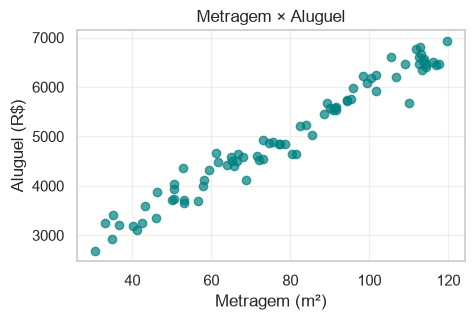

Correlação Metragem × Aluguel: r = 0.982


In [16]:
# Gráfico de dispersão
plt.figure(figsize=(5, 3))
plt.scatter(imoveis['Metragem (m²)'], imoveis['Aluguel (R$)'], alpha=0.7, color='teal')
plt.xlabel('Metragem (m²)')
plt.ylabel('Aluguel (R$)')
plt.title('Metragem × Aluguel')
plt.grid(True, alpha=0.3)
plt.show()

# Correlação
r_metragem_aluguel = imoveis['Metragem (m²)'].corr(imoveis['Aluguel (R$)'])
print(f'Correlação Metragem × Aluguel: r = {r_metragem_aluguel:.3f}')

## 9. Exercícios

Escolha **dois** dos exemplos abaixo e:

1. **Crie um dataset simulado** com pelo menos 50 observações para cada par de variáveis
2. **Gere um gráfico de dispersão** para visualizar a relação
3. **Calcule a covariância** e a **correlação de Pearson**
4. **Interprete os resultados**: a correlação é forte ou fraca? Positiva ou negativa? Faz sentido?

---

### Opções de temas

**Opção 1 — Horas de exercício × % de gordura corporal**
- Crie dados onde pessoas que exercitam mais tendem a ter menor % de gordura
- Use uma relação linear com algum ruído para simular variação real

**Opção 2 — Investimento em anúncios × Vendas**
- Crie dados onde maior investimento em anúncios gera mais vendas
- Pense: qual seria um valor base de vendas mesmo sem investimento?

**Opção 3 — Escolha livre**
- Pense em outro par de variáveis do seu dia a dia que possam estar correlacionadas
- Justifique por que espera essa correlação

---

### Entrega

- Notebook Python com os passos acima
- Gráficos com títulos e rótulos nos eixos
- Breve parágrafo de interpretação (3-5 linhas)